In [1]:
import numpy as np
import scipy.stats as sps

import matplotlib.pyplot as plt

## Estimating $\pi$
\begin{align}
\frac{\text{Area of circle}}{\text{Area of square}} &= \frac{\pi r^2}{4r^2}\\
&= \frac{\pi}{4}
\end{align}

15 mins

In [2]:
100_000, 1e5

(100000, 100000.0)

In [3]:
num_trials = int(1e7)
r = 2

# Drawing a bunch of points in a square
samples = np.random.uniform(low=-1*r, high=r, size=(2, num_trials))

In [4]:
# Counting those inside the circle
dist = np.sqrt(np.sum(samples**2, axis=0))

In [5]:
mask = dist<=r

In [6]:
# Estimating pi
pi_hat = 4.*np.sum(mask)/num_trials

In [7]:
pi_hat

np.float64(3.1406564)

/home/peaelle42/miniconda3/envs/py311/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/peaelle42/miniconda3/envs/py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


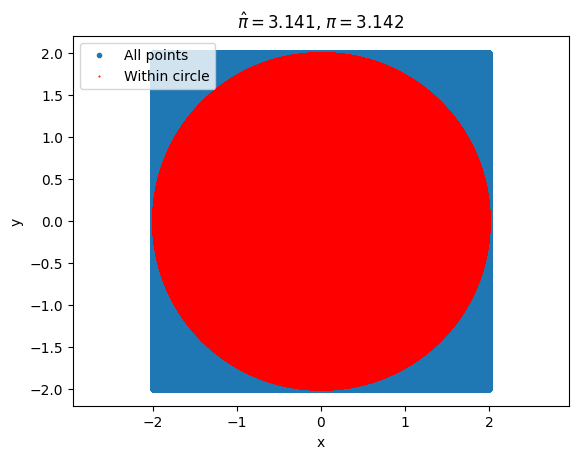

In [8]:
plt.plot(samples[0,:], samples[1,:], '.', label='All points')
plt.plot(samples[0,mask], samples[1,mask], 'r.', ms=1, label='Within circle')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.title(f'$\hat{{\pi}}=${pi_hat:.3f}, $\pi=${np.pi:.3f}')
plt.legend()

## Inverse transform sampling
10 mins

In [9]:
mu, sigma = 1.1, 0.3
target_pdf = sps.norm(loc=mu, scale=sigma)

n_samples = 1000

In [10]:
yy = np.random.uniform(low=0., high=1., size=n_samples)
xx = target_pdf.ppf(yy)
xx_sorted = np.sort(xx)

Text(0, 0.5, 'PDF')

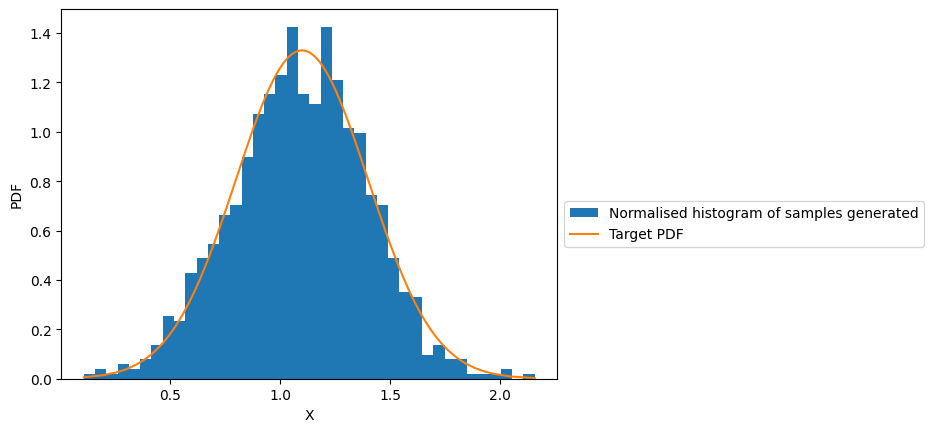

In [11]:
plt.hist(xx, bins=40, density=True, label='Normalised histogram of samples generated')
plt.plot(xx_sorted, target_pdf.pdf(xx_sorted), label='Target PDF')
plt.legend(bbox_to_anchor=(1., 0.5), loc='upper left')
plt.xlabel('X')
plt.ylabel('PDF')

## Accept-reject algorithm
15 mins

In [12]:
mu, sigma = 5.1, 0.3
target_pdf = sps.norm(loc=mu, scale=sigma)

n_samples = int(1e5)

In [13]:
# Decide range to sample X from
min_x = mu-5*sigma
max_x = mu+5*sigma

# Candidates
xx = np.random.uniform(low=min_x, high=max_x, size=n_samples)

# See which samples to accept
fmax = target_pdf.pdf(mu)
uu = np.random.uniform(low=0., high=fmax, size=n_samples)
#uu = np.random.uniform(low=0., high=1., size=n_samples) <----- bug lol
mask = (uu<target_pdf.pdf(xx))
accepted_xx = xx[mask]

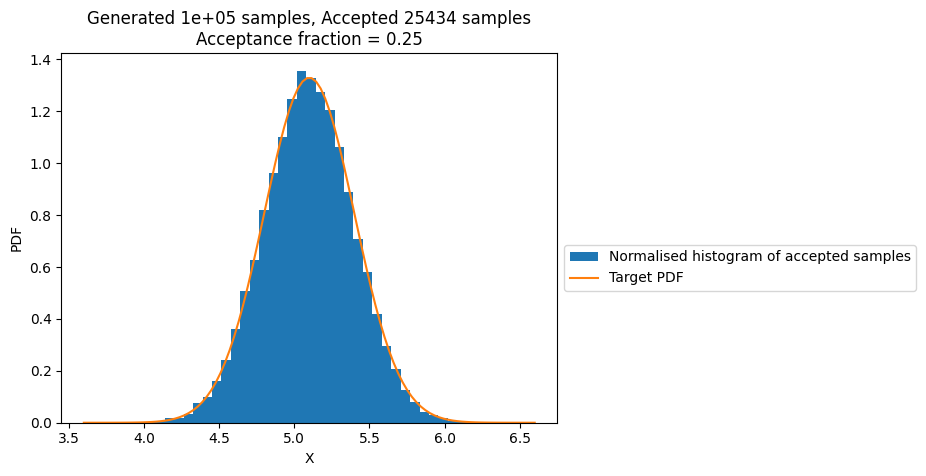

In [14]:
support_arr = np.linspace(min_x, max_x, 100)

plt.hist(accepted_xx, bins=40, density=True, label='Normalised histogram of accepted samples')
plt.plot(support_arr, target_pdf.pdf(support_arr), label='Target PDF')
plt.title(f'Generated {n_samples:.0e} samples, Accepted {np.sum(mask)} samples\nAcceptance fraction = {np.sum(mask)/n_samples:.2f}')
plt.xlabel('X')
plt.ylabel('PDF')
plt.legend(bbox_to_anchor=(1., 0.5), loc='upper left')